# Unbiased simulations

### Outline
1. Simulation parameters
2. Perform simulations and write dihedral & feature data
3. Gather data from steps into master files

### Input:
* `data/ala2_solv.pdb`

### Output, for $n\in[0,\mathrm{num\_steps}]$:
* `workdir/n/traj.h5`
* `workdir/n/traj.out`
* `workdir/n/dihedrals.npy`
* `workdir/n/features.npy`
 
# 1. Simulation parameters

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import openmm as mm
import openmm.unit as unit
from openmm.app import Simulation, ForceField, PDBFile, HBonds
from src.param import SimulationParameters
from src.util import save_pickle

p = SimulationParameters(working_dir = 'data/unbiased-test',
                         simulation_time = 10 * unit.picosecond)
save_pickle(f'{p.working_dir}/sim_params.pickle', p)
p.__dict__

working_dir = data/unbiased-test
pdb_file = data/ala2_solv.pdb
simulation_time = 10 ps
lagtime = 1 ps
temperature = 300 K
timestep = 0.002 ps
friction_coeff = 1 /ps
bias_factor = 5.0
dist_regularization = 0.002
num_steps = 5000
num_frames = 10
num_steps_per_frame = 500
report_interval = 500
ns = 0.0
num_features = 45
num_eigvecs = 6
num_cvs = 2
loss_method = vamp2
learning_rate = 0.005
frac_test = 0.1


# 2. Perform simulations and write dihedral & feature data

In [ ]:
from src.data import simulation_data
from src.util import create_system, state_data_reporter, hdf5_reporter

step_start = 0
num_steps = 5
do_simulation = True

if do_simulation:
    pdb = PDBFile(p.pdb_file)
    forcefield = ForceField('amber99sb.xml', 'tip3p.xml')
    system = create_system(forcefield, pdb.topology)

    for step in range(step_start, num_steps):
        print(f'starting simulation {step} of {num_steps}')

        # start positions: current 'sd' is from previous step
        if step == 0:
            start_positions = pdb.positions
        else:
            if 'sd' not in locals():
                sd = simulation_data(p, subdir=(step - 1))
            start_positions = sd.final_positions
        assert type(start_positions) == mm.unit.quantity.Quantity, \
        f'ERROR: {type(start_positions) = } in step {step}'

        # new 'sd' object for present simulation files
        sd = simulation_data(p, subdir=step)
        outfile = str(sd.files['outfile'])
        h5file = str(sd.files['h5file'])

        # run simulation: each step requires new integrator, simulation object
        integrator = mm.LangevinIntegrator(p.temperature, p.friction_coeff, p.timestep)
        simulation = Simulation(pdb.topology, system, integrator)
        simulation.context.setPositions(start_positions)
        sdr = state_data_reporter(outfile, p.report_interval)
        hdr = hdf5_reporter(h5file, p.report_interval)
        simulation.reporters.append(sdr)
        simulation.reporters.append(hdr)
        # simulation.step(p.timesteps_per_frame * p.num_frames)
        simulation.step(round(p.simulation_time / p.timestep))

        for reporter in simulation.reporters:
            if hasattr(reporter, 'close'):
                reporter.close()

        # save 'final_positions'
        r = simulation.context.getState(getPositions=True).getPositions()
        sd.save_and_assign_objects({'final_positions': r})

        # calculate and save 'dihedrals', 'features' from 'h5file'
        sd.save_feature_data(recalculate=True)

# 3. Gather data from steps into master files

* Concatenate `dihedrals`, `features` arrays from each step
* Write combined data files to `p.working_dir`

Loaded SimulationData object from data/unbiased-test/step_0 with 10 frames
Loaded SimulationData object from data/unbiased-test/step_1 with 10 frames
Loaded SimulationData object from data/unbiased-test/step_2 with 10 frames
Loaded SimulationData object from data/unbiased-test/step_3 with 10 frames
Loaded SimulationData object from data/unbiased-test/step_4 with 10 frames
Loaded SimulationData object from data/unbiased-test with 50 frames
sd.dihedrals.shape = (50, 2)


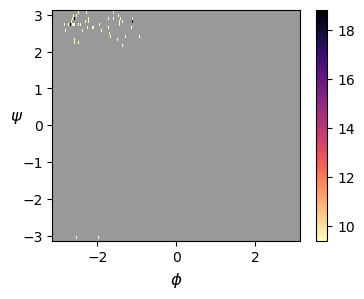

In [24]:
from src.plots import plot_dihedrals_hist2d

dihedrals, features = [], []
for step in range(num_steps):
    sd = simulation_data(p, subdir=step)
    dihedrals.append(sd.dihedrals)
    features.append(sd.features)

sd = simulation_data(p)
sd.save_and_assign_objects({'dihedrals': np.vstack(sd.dihedrals),
                            'features': np.vstack(sd.features)})

print(f'{sd.dihedrals.shape = }')
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
plot_dihedrals_hist2d(fig, ax, sd.dihedrals)
# fig.savefig('figures/dihedral-hist2d-solv.png', bbox_inches='tight')